# 04. DataSAIL and ESA repair audit

**Purpose.** Audit two archived DataSAIL split outputs and run a compact ESA repair on the same splits.

**Inputs.**
- `data/demo/datasail_esa_cases/raw_datasail_splits/ames/`
- `data/demo/datasail_esa_cases/raw_datasail_splits/pkb/`

**Main outputs.**
- `raw_datasail_summary.csv`
- `compact_esa_summary.csv`
- `datasail_vs_compact_esa_summary.csv`
- `datasail_vs_compact_esa_leakage.csv`

**Expected observation.** Compact ESA changes no-scaffold split composition while retaining the archived scaffold-bearing assignment.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'pyproject.toml').exists():
    raise RuntimeError('Run this notebook from the project root or notebooks/ directory.')

SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from empty_scaffold.leakage import load_split_csv, summarize_split_leakage
from empty_scaffold.esa_repair import repair_archived_datasail_split, write_repaired_split_tables

CASE_ROOT = PROJECT_ROOT / 'data' / 'demo' / 'datasail_esa_cases'
RAW_ROOT = CASE_ROOT / 'raw_datasail_splits'
OUT_DIR = PROJECT_ROOT / 'outputs' / 'notebook_04_datasail_esa_audit'
REPAIRED_OUT_ROOT = OUT_DIR / 'compact_esa_repaired_splits'
OUT_DIR.mkdir(parents=True, exist_ok=True)
REPAIRED_OUT_ROOT.mkdir(parents=True, exist_ok=True)

SMILES_COLUMN = 'molecules'
THRESHOLD = 0.4
ESA_CONDITION = 'D_train_support_priority'
DEMO_DATASETS = ['ames', 'pkb']

print('Project root:', PROJECT_ROOT.name)
print('Raw split root:', RAW_ROOT.relative_to(PROJECT_ROOT))
print('Output directory:', OUT_DIR.relative_to(PROJECT_ROOT))

Project root: empty-scaffold
Raw split root: data/demo/datasail_esa_cases/raw_datasail_splits
Output directory: outputs/notebook_04_datasail_esa_audit


## 1. Archived raw DataSAIL splits

The split CSVs are treated as archived DataSAIL outputs. DataSAIL itself is not rerun here.

In [2]:
raw_split_dirs = []
for dataset in DEMO_DATASETS:
    split_dir = RAW_ROOT / dataset
    missing = [s for s in ['train', 'valid', 'test'] if not (split_dir / f'{s}.csv').exists()]
    if missing:
        raise FileNotFoundError(f'{dataset}: missing split files: {missing}')
    raw_split_dirs.append(split_dir)

pd.DataFrame({
    'dataset': [p.name for p in raw_split_dirs],
    'split_dir': [str(p.relative_to(PROJECT_ROOT)) for p in raw_split_dirs],
})

,dataset,split_dir
0,ames,data/demo/datasail_esa_cases/raw_datasail_spli...
1,pkb,data/demo/datasail_esa_cases/raw_datasail_spli...


In [3]:
def audit_split_dir(split_dir, scenario, smiles_column=SMILES_COLUMN):
    frames = {}
    for split in ['train', 'valid', 'test']:
        frames[split] = load_split_csv(split_dir / f'{split}.csv', smiles_column=smiles_column)

    total = sum(len(df) for df in frames.values())
    total_ns = sum(int(df['no_scaffold'].sum()) for df in frames.values())
    overall_prop = total_ns / total if total else np.nan

    rows = []
    split_props = {}
    for split, df in frames.items():
        n = int(len(df))
        n_ns = int(df['no_scaffold'].sum()) if n else 0
        prop = n_ns / n if n else np.nan
        split_props[split] = prop
        rows.append({
            'scenario': scenario,
            'dataset': split_dir.name,
            'split': split,
            'n_molecules': n,
            'n_no_scaffold': n_ns,
            'no_scaffold_proportion': prop,
            'overall_no_scaffold_proportion': overall_prop,
            'support_recovery_vs_overall': prop / overall_prop if overall_prop else np.nan,
        })

    summary = {
        'scenario': scenario,
        'dataset': split_dir.name,
        'n_molecules': int(total),
        'n_no_scaffold': int(total_ns),
        'overall_no_scaffold_proportion': overall_prop,
        'train_no_scaffold_proportion': split_props.get('train', np.nan),
        'valid_no_scaffold_proportion': split_props.get('valid', np.nan),
        'test_no_scaffold_proportion': split_props.get('test', np.nan),
        'support_recovery': split_props.get('train', np.nan) / overall_prop if overall_prop else np.nan,
        'sink_ratio': max(split_props.get('valid', np.nan), split_props.get('test', np.nan)) / split_props.get('train', np.nan)
                      if split_props.get('train', np.nan) else np.nan,
    }
    return pd.DataFrame(rows), summary

raw_audit_tables = []
raw_summary_rows = []
for split_dir in raw_split_dirs:
    audit_df, summary = audit_split_dir(split_dir, scenario='raw_datasail')
    raw_audit_tables.append(audit_df)
    raw_summary_rows.append(summary)

raw_audit = pd.concat(raw_audit_tables, ignore_index=True)
raw_summary = pd.DataFrame(raw_summary_rows).sort_values('dataset').reset_index(drop=True)
raw_audit.to_csv(OUT_DIR / 'raw_datasail_split_audit.csv', index=False)
raw_summary.to_csv(OUT_DIR / 'raw_datasail_summary.csv', index=False)

raw_summary

,scenario,dataset,n_molecules,n_no_scaffold,overall_no_scaffold_proportion,train_no_scaffold_proportion,valid_no_scaffold_proportion,test_no_scaffold_proportion,support_recovery,sink_ratio
0,raw_datasail,ames,7653,1294,0.169084,0.032279,0.954795,0.546080,0.190904,29.579534
1,raw_datasail,pkb,3662,591,0.161387,0.027628,0.953890,0.512968,0.171191,34.526183


In [4]:
raw_audit.pivot_table(
    index='dataset',
    columns='split',
    values='no_scaffold_proportion',
    aggfunc='first',
).reset_index()

split,dataset,test,train,valid
0,ames,0.546080,0.032279,0.954795
1,pkb,0.512968,0.027628,0.953890


## 2. Compact ESA repair

Scaffold-bearing molecules keep their archived DataSAIL branch. No-scaffold molecules are reassigned by ESA.

In [5]:
repair_audit_tables = []
repair_summary_rows = []
cluster_tables = []

for split_dir in raw_split_dirs:
    dataset = split_dir.name
    split_tables, assignment_audit, cluster_summary = repair_archived_datasail_split(
        split_dir,
        condition_name=ESA_CONDITION,
        smiles_column=SMILES_COLUMN,
        seed=42,
    )
    repaired_dir = REPAIRED_OUT_ROOT / dataset
    write_repaired_split_tables(split_tables, repaired_dir)

    assignment_audit.to_csv(repaired_dir / 'split_assignment_audit.csv', index=False)
    cluster_summary.to_csv(repaired_dir / 'esa_coupled_cluster_summary.csv', index=False)

    audit_df, summary = audit_split_dir(repaired_dir, scenario='compact_esa')
    repair_audit_tables.append(audit_df)
    repair_summary_rows.append(summary)

    tmp = cluster_summary.copy()
    tmp.insert(0, 'dataset', dataset)
    cluster_tables.append(tmp)

compact_esa_audit = pd.concat(repair_audit_tables, ignore_index=True)
compact_esa_summary = pd.DataFrame(repair_summary_rows).sort_values('dataset').reset_index(drop=True)
compact_esa_clusters = pd.concat(cluster_tables, ignore_index=True)

compact_esa_audit.to_csv(OUT_DIR / 'compact_esa_split_audit.csv', index=False)
compact_esa_summary.to_csv(OUT_DIR / 'compact_esa_summary.csv', index=False)
compact_esa_clusters.to_csv(OUT_DIR / 'compact_esa_cluster_summary.csv', index=False)

compact_esa_summary

,scenario,dataset,n_molecules,n_no_scaffold,overall_no_scaffold_proportion,train_no_scaffold_proportion,valid_no_scaffold_proportion,test_no_scaffold_proportion,support_recovery,sink_ratio
0,compact_esa,ames,7653,1294,0.169084,0.165716,0.611765,0.133858,0.980080,3.691648
1,compact_esa,pkb,3662,591,0.161387,0.158846,0.589744,0.119792,0.984253,3.712679


In [6]:
combined_summary = pd.concat([raw_summary, compact_esa_summary], ignore_index=True)
combined_summary.to_csv(OUT_DIR / 'datasail_vs_compact_esa_summary.csv', index=False)

combined_summary[[
    'scenario', 'dataset',
    'overall_no_scaffold_proportion',
    'train_no_scaffold_proportion',
    'valid_no_scaffold_proportion',
    'test_no_scaffold_proportion',
    'support_recovery',
    'sink_ratio',
]]

,scenario,dataset,overall_no_scaffold_proportion,train_no_scaffold_proportion,valid_no_scaffold_proportion,test_no_scaffold_proportion,support_recovery,sink_ratio
0,raw_datasail,ames,0.169084,0.032279,0.954795,0.546080,0.190904,29.579534
1,raw_datasail,pkb,0.161387,0.027628,0.953890,0.512968,0.171191,34.526183
2,compact_esa,ames,0.169084,0.165716,0.611765,0.133858,0.980080,3.691648
3,compact_esa,pkb,0.161387,0.158846,0.589744,0.119792,0.984253,3.712679


## 3. Split-composition comparison

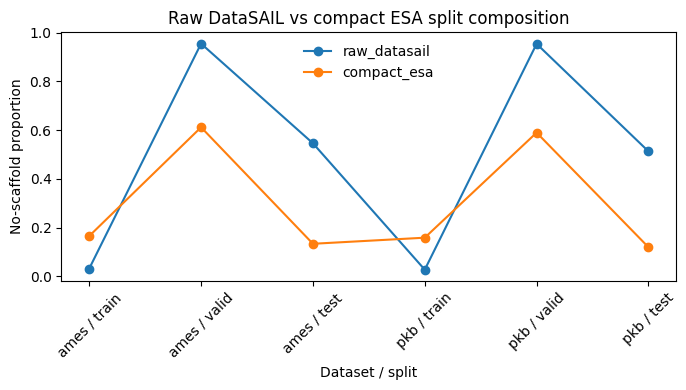

In [7]:
prop_rows = []
for _, row in combined_summary.iterrows():
    for split in ['train', 'valid', 'test']:
        prop_rows.append({
            'dataset': row['dataset'],
            'scenario': row['scenario'],
            'split': split,
            'no_scaffold_proportion': row[f'{split}_no_scaffold_proportion'],
        })
prop_long = pd.DataFrame(prop_rows)
prop_long.to_csv(OUT_DIR / 'datasail_vs_compact_esa_split_proportions_long.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 4))
plot_df = prop_long.copy()
plot_df['x_label'] = plot_df['dataset'] + ' / ' + plot_df['split']
for scenario in ['raw_datasail', 'compact_esa']:
    sub = plot_df[plot_df['scenario'] == scenario]
    ax.plot(sub['x_label'], sub['no_scaffold_proportion'], marker='o', label=scenario)
ax.set_ylabel('No-scaffold proportion')
ax.set_xlabel('Dataset / split')
ax.set_title('Raw DataSAIL vs compact ESA split composition')
ax.tick_params(axis='x', rotation=45)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / 'datasail_vs_compact_esa_split_composition.png', dpi=200)
plt.show()

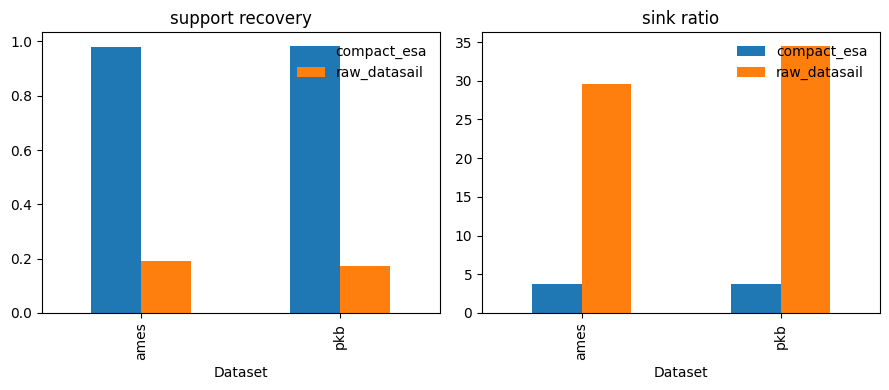

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for metric, ax in [('support_recovery', axes[0]), ('sink_ratio', axes[1])]:
    pivot = combined_summary.pivot_table(index='dataset', columns='scenario', values=metric, aggfunc='first').sort_index()
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(metric.replace('_', ' '))
    ax.set_xlabel('Dataset')
    ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / 'datasail_vs_compact_esa_support_sink.png', dpi=200)
plt.show()

## 4. Train-facing leakage metrics

The reference set is all training molecules.

In [9]:
leakage_rows = []
for scenario, dirs in [
    ('raw_datasail', raw_split_dirs),
    ('compact_esa', [REPAIRED_OUT_ROOT / dataset for dataset in DEMO_DATASETS]),
]:
    for split_dir in dirs:
        row = summarize_split_leakage(
            split_dir,
            smiles_column=SMILES_COLUMN,
            threshold=THRESHOLD,
            include_valid=True,
        )
        row['scenario'] = scenario
        row['split_dir'] = str(split_dir.relative_to(PROJECT_ROOT))
        leakage_rows.append(row)

leakage = pd.DataFrame(leakage_rows).sort_values(['dataset', 'scenario']).reset_index(drop=True)
leakage.to_csv(OUT_DIR / 'datasail_vs_compact_esa_leakage.csv', index=False)

leakage[[
    'scenario', 'dataset',
    'train_no_scaffold_fp', 'valid_no_scaffold_fp', 'test_no_scaffold_fp',
    'mean_maxsim_valid_ns_to_train_all', 'leakrate_at_0.4_valid_ns_to_train_all', 'L_norm_valid_ns_to_train_all',
    'mean_maxsim_test_ns_to_train_all', 'leakrate_at_0.4_test_ns_to_train_all', 'L_norm_test_ns_to_train_all',
]]

,scenario,dataset,train_no_scaffold_fp,valid_no_scaffold_fp,test_no_scaffold_fp,mean_maxsim_valid_ns_to_train_all,leakrate_at_0.4_valid_ns_to_train_all,L_norm_valid_ns_to_train_all,mean_maxsim_test_ns_to_train_all,leakrate_at_0.4_test_ns_to_train_all,L_norm_test_ns_to_train_all
0,compact_esa,ames,1191,52,51,0.360937,0.250000,0.035060,0.334569,0.196078,0.019089
1,raw_datasail,ames,200,697,397,0.366001,0.296987,0.050893,0.286981,0.100756,0.029226
2,compact_esa,pkb,545,23,23,0.390686,0.478261,0.048593,0.337813,0.260870,0.034274
3,raw_datasail,pkb,82,331,178,0.377557,0.320242,0.046753,0.343042,0.235955,0.042124


## Generated files

In [10]:
for path in sorted(OUT_DIR.rglob('*')):
    if path.is_file():
        print(path.relative_to(PROJECT_ROOT))

outputs/notebook_04_datasail_esa_audit/compact_esa_cluster_summary.csv
outputs/notebook_04_datasail_esa_audit/compact_esa_repaired_splits/ames/esa_coupled_cluster_summary.csv
outputs/notebook_04_datasail_esa_audit/compact_esa_repaired_splits/ames/split_assignment_audit.csv
outputs/notebook_04_datasail_esa_audit/compact_esa_repaired_splits/ames/test.csv
outputs/notebook_04_datasail_esa_audit/compact_esa_repaired_splits/ames/train.csv
outputs/notebook_04_datasail_esa_audit/compact_esa_repaired_splits/ames/valid.csv
outputs/notebook_04_datasail_esa_audit/compact_esa_repaired_splits/pkb/esa_coupled_cluster_summary.csv
outputs/notebook_04_datasail_esa_audit/compact_esa_repaired_splits/pkb/split_assignment_audit.csv
outputs/notebook_04_datasail_esa_audit/compact_esa_repaired_splits/pkb/test.csv
outputs/notebook_04_datasail_esa_audit/compact_esa_repaired_splits/pkb/train.csv
outputs/notebook_04_datasail_esa_audit/compact_esa_repaired_splits/pkb/valid.csv
outputs/notebook_04_datasail_esa_audit